###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2018  by D. Koehn, T. Meier and R. Hartmann, notebook style sheet by L.A. Barba, N.C. Clementi

# Correlation of Signals: Correlation Coefficients

In order to examine the similarity between time series, measures must first be defined. In this lecture, I will discuss the advantages and disadvantages of various correlation measures and explain their applications to time series of varying complexity. The first correlation measure we will consider is the correlation coefficient.

## The correlation coefficient

Let $\{x_j\}$ and $\{y_j\}$ be two time series with $n$ discrete time samples; the similarity between the two signals can then be quantified by the **correlation coefficient** $\tilde{\rho}_{x,y}\in[-1,1]$:

\begin{equation}
\tilde{\rho}_{x,y}=\frac{\sum\limits_{j}^nx_{j}y_{j}}{\sqrt{\sum\limits_{j}^nx_{j}^{2}\cdot\sum\limits_{j}^ny_{j}^{2}}},\\ \notag
\end{equation}

where the sum of the squares of the two time series must be non-zero:

$$
\sum\limits_{j}^nx_{j}^{2} \ne 0,\; \sum\limits_{j}^ny_{j}^{2} \ne 0\notag
$$


The larger $|\tilde{\rho}_{x,y}|$ is, the more similar the behaviour of the two sequences is.

Let's illustrate the correlation coefficient using a few simple examples. First, we define a time series consisting of a sine function with a frequency $f_0$ of 5 Hz

$$
x = \sin(\omega t) = \sin(2 \pi f_0 t) \notag
$$

where we have used the definition of the angular frequency $\omega$. In discrete form, this gives

$$
x_j = \sin(2 \pi f_0 j dt) \notag
$$

with the sampling interval $dt$ and $t = j dt$

In [1]:
# Import Python Libraries 
# -----------------------
import numpy                      # NumPy
from scipy.stats import pearsonr  # Function Correlation Coefficient 
from gsv.gsv_func import *        # Library "Digital Signal Processing in Geophysics"

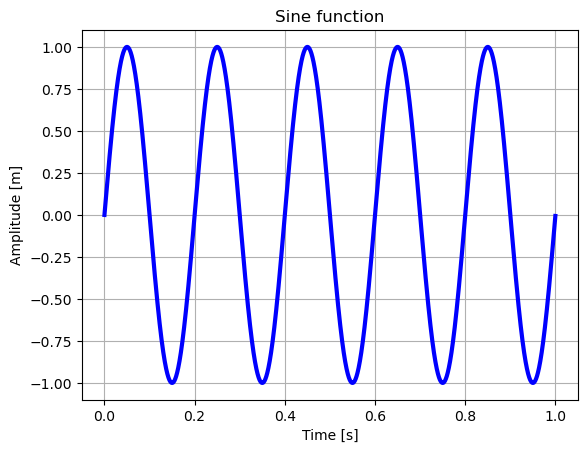

In [2]:
# Define Sine Function
# --------------------
f0 = 5   # frequency of sine function [Hz]
time, sinus = create_sine(f0)

# Plot Sine function
draw_func(time,sinus,'Sine function', 'Time [s]', 'Amplitude [m]')

First, we calculate the correlation coefficient of the sine function with itself. To do this, we use the SciPy function `Pearsonr`

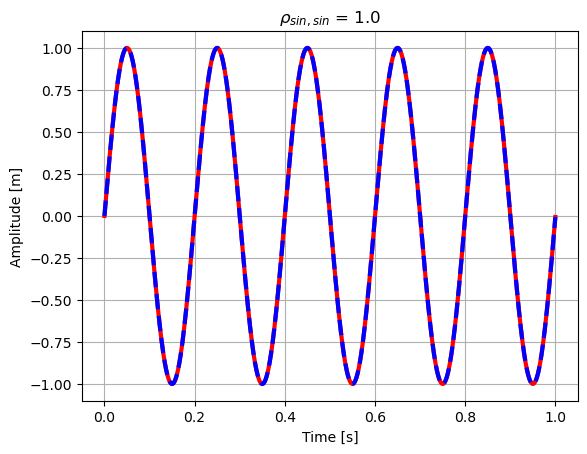

In [3]:
# Compute correlation coefficient of sine function with itself
rho_sin_sin = pearsonr(sinus,sinus)

# Plot function and correlation coefficient
draw_corr(time,sinus,sinus,r'$\rho_{sin,sin}$', 'Time [s]', 'Amplitude [m]',rho_sin_sin)

Since the sine function correlates perfectly with itself, we obtain a correlation coefficient:

$$\tilde{\rho}_{sin,sin} = 1$$

What happens if we increase the amplitude of the sine function by a factor of a?

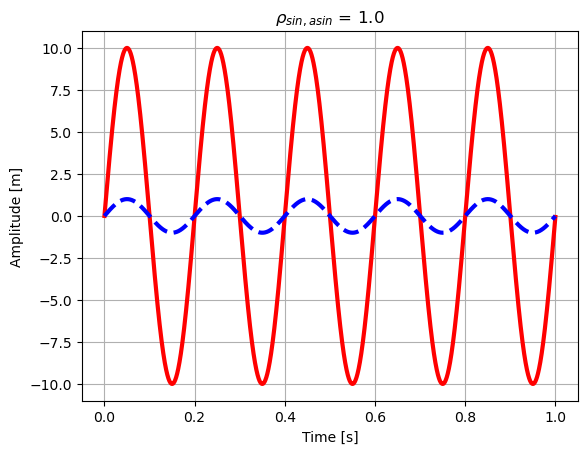

In [4]:
# Compute correlation coefficient of sine function with a * sine function
a = 10
asinus = a * sinus
rho_sin_asin = pearsonr(sinus,asinus)

# Plot function an correlation coefficient
draw_corr(time,sinus,asinus,r'$\rho_{sin,asin}$', 'Time [s]', 'Amplitude [m]',rho_sin_asin)

According to the correlation coefficient, the correlation 

$$ \tilde{\rho}_{sin,asin} = 1 $$

still appears to be perfect. This is not really surprising, as the correlation coefficient is, by definition, normalised:

\begin{equation}
\tilde{\rho}_{x,y}=\frac{\sum\limits_{j}^nx_{j}y_{j}}{\sqrt{\sum\limits_{j}^nx_{j}^{2}\cdot\sum\limits_{j}^ny_{j}^{2}}},\\ \notag
\end{equation}

If, for example, we substitute 

$$x_j \rightarrow a x_j$$

then we obtain

\begin{equation}
\tilde{\rho}_{x,y}=\frac{\sum\limits_{j}^nax_{j}y_{j}}{\sqrt{\sum\limits_{j}^na^2x_{j}^{2}\cdot\sum\limits_{j}^ny_{j}^{2}}},\\ \notag
\end{equation}

or

\begin{equation}
\tilde{\rho}_{x,y}=\frac{a\sum\limits_{j}^nx_{j}y_{j}}{a\sqrt{\sum\limits_{j}^nx_{j}^{2}\cdot\sum\limits_{j}^ny_{j}^{2}}},\\ \notag
\end{equation}

so that any factor $a$ can be cancelled out.

If we reverse the phase of a sine function, we obtain an ...

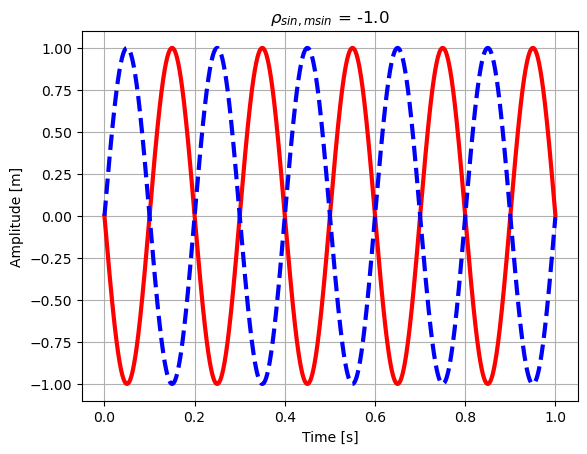

In [5]:
# Compute correlation coefficient of sine function with -1 * sine function
msinus = - sinus
rho_sin_msin = pearsonr(sinus,msinus)

# Plot function and correlation coefficient
draw_corr(time,sinus,msinus,r'$\rho_{sin,msin}$', 'Time [s]', 'Amplitude [m]',rho_sin_msin)

... **Anticorrelation**, as indicated by a negative correlation coefficient 

$$ \tilde{\rho}_{sin,msin} = -1 $$

Realistically, one would never record a time series without measurement errors. Let’s add some normally distributed noise with an amplitude of 0.1 m ...

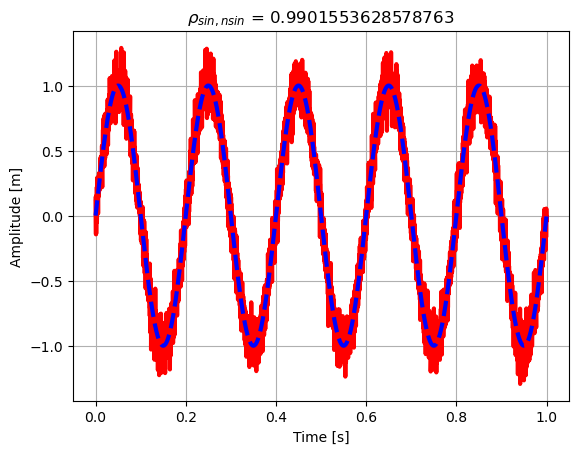

In [6]:
# Generate normal distributed noise 
noise_amp = 0.1
noise = numpy.random.normal(0,noise_amp,len(time)) 

# Add noise to sine function
nsinus =  sinus + noise

# Compute correlation coefficient of sine function with sine function + noise
rho_sin_nsin = pearsonr(sinus,nsinus)

# Plot function with correlation coefficient
draw_corr(time,sinus,nsinus,r'$\rho_{sin,nsin}$', 'Time [s]', 'Amplitude [m]',rho_sin_nsin)

Even with a noise amplitude of 10%, the correlation coefficient is still very high. If we increase the noise amplitude ‘slightly’ further to 1000% ...

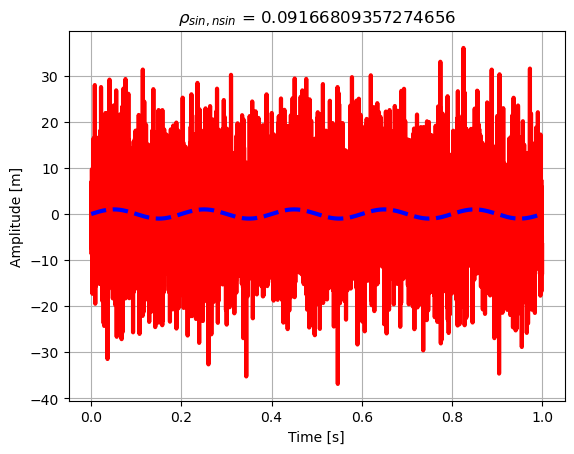

In [8]:
# Generate normal distributed noise 
noise_amp = 10
noise = numpy.random.normal(0,noise_amp,len(time)) 

# Add noise to sine function
nsinus =  sinus + noise

# Compute correlation coefficient of sine function with sine function + noise
rho_sin_nsin = pearsonr(sinus,nsinus)

# Plot function with correlation coefficient
draw_corr(time,sinus,nsinus,r'$\rho_{sin,nsin}$', 'Time [s]', 'Amplitude [m]',rho_sin_nsin)

... this results in a very low correlation of 

$$\rho_{sin,nsin} = 0.09$$

If the correlation coefficient were zero, the two time series would be **uncorrelated**.

In summary, therefore:

\begin{equation}
\begin{split}
\tilde{\rho}_{x,y}&=
\begin{cases}
1&\{x_j\}\text{ und }\{y_j\}\text{ are identical up to a factor }a>0\\
%&\{x_j\}=a\cdot\{y_j\}\text{ with }a>0\\
0&\{x_j\}\text{ und }\{y_j\}\text{ uncorrelated}\\
-1&\{x_j\}\text{ und }\{y_j\}\text{ are identical up to a factor }a<0 \text{ (anticorrelated)}\\
%&\{x_j\}=a\cdot\{y_j\}\text{ with }a<0 (anticorrelated)
\end{cases}
\end{split}
\notag
\end{equation}

The larger $|\tilde{\rho}_{x,y}|$ is, the more similar the two time series are.

## Examples of applications for time series correlation

Let’s first look at two time series that have, to some extent, led to a veritable war of beliefs. How well does the average CO₂ concentration in the Earth’s atmosphere correlate with the average surface temperature over the last few millennia? Relevant time series can be found, for example, here on [klimafakten.de](https://www.klimafakten.de/behauptungen/behauptung-der-co2-anstieg-ist-nicht-ursache-sondern-folge-des-klimawandels). The very strong correlation between the two time series in Fig. 1 seems, at first glance, to prove a clear link between atmospheric CO₂ concentration and temperature variation. But hang on a moment – the CO₂ signal appears, in some cases, to lag behind temperature variation. Climate change deniers argue that this is proof of a lack of a **cause-and-effect relationship** between temperature and atmospheric CO₂ levels. A scientist would cite the reduced solubility of CO₂ as the reason for this effect when water temperature rises. When the temperature subsequently falls, the CO₂ that has been released is not immediately re-dissolved in the water. Quite apart from the fact that, on a timescale of 400,000 years, temperature variations depend not only on CO₂ levels but also, for example, on orbital variations ([Milanković cycles](https://de.wikipedia.org/wiki/Milankovi%C4%87-Zyklen)). 

Another well-known correlation: the number of storks is said to correlate very strongly with the birth rate, as shown, for example, in this paper 

[Matthews (2001), Storks Deliver Babies (p=0.008), Teaching Statistics ](https://onlinelibrary.wiley.com/doi/abs/10.1111/1467-9639.00013)

This example shows that correlation measures can often be used to demonstrate a certain degree of correlation. However, one must **not** conclude from this that a **cause-and-effect relationship** exists between the time series. It is possible to find almost perfect correlations or anti-correlations between time series between which there is no cause-and-effect relationship. Some excellent examples can be found here:

[Spurious correlation](https://www.tylervigen.com/spurious-correlations)

Finally, here is an example I came across a few years ago. The figure below shows a relatively good correlation between the density/S-wave velocity model that I derived using [seismic full-waveform inversion (FWI) from an SH dataset at the Kleinneudorf site](https://www.researchgate.net/publication/329802721_Charakterisierung_einer_Storungszone_ostlich_des_Grossen_Ploner_Sees_Schleswig-Holstein_mittels_2D_SH_Full_Waveform_Inversion) and the drill core data from the geologists

<img src="images/KN_FWI_vs_borehole.jpg" style="width: 800px;"/>

There are clear cause-and-effect relationships. The density model derived from seismic data should correlate with the density measured from the drill core. The ‘number of blows per metre’ required to drive the borehole into the subsurface is greater when shear strength (S-wave velocity) is high than when it is low. The good correlation between borehole data and the FWI results, combined with a cause-and-effect relationship, would therefore confirm the results of the seismic inversion. 

The problem is that the borehole data came from a borehole situated 50 metres further north. The good correlation is therefore also purely coincidental in this case, despite a plausible cause-and-effect relationship.

## Summary:

- The correlation coefficient can be used to quantify the degree of correlation between two time series

- However, a strong correlation between time series is not proof of a cause-and-effect relationship

- Even where there is a cause-and-effect relationship, a high correlation between time series may still be purely coincidental